In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/models/google/gemma-4/transformers/gemma-4-e4b-it/1/config.json
/kaggle/input/models/google/gemma-4/transformers/gemma-4-e4b-it/1/README.md
/kaggle/input/models/google/gemma-4/transformers/gemma-4-e4b-it/1/tokenizer.json
/kaggle/input/models/google/gemma-4/transformers/gemma-4-e4b-it/1/tokenizer_config.json
/kaggle/input/models/google/gemma-4/transformers/gemma-4-e4b-it/1/chat_template.jinja
/kaggle/input/models/google/gemma-4/transformers/gemma-4-e4b-it/1/model.safetensors
/kaggle/input/models/google/gemma-4/transformers/gemma-4-e4b-it/1/processor_config.json
/kaggle/input/models/google/gemma-4/transformers/gemma-4-e4b-it/1/generation_config.json
/kaggle/input/datasets/iamsouravbanerjee/animal-image-dataset-90-different-animals/name of the animals.txt
/kaggle/input/datasets/iamsouravbanerjee/animal-image-dataset-90-different-animals/animals/animals/beetle/687486f1cb.jpg
/kaggle/input/datasets/iamsouravbanerjee/animal-image-dataset-90-different-animals/animals/animals/bee

In [2]:
pip install --upgrade transformers -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 95.8 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.5/645.5 kB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 117.2 MB/s eta 0:00:0000:01
Note: you may need to restart the kernel to use updated packages.


参考資料 
gemma4_application
-> https://huggingface.co/blog/gemma4

# モデルのダウンロード 

In [3]:
import kagglehub
import torch
from transformers import AutoProcessor, AutoModelForCausalLM

MODEL_PATH = kagglehub.model_download("google/gemma-4/transformers/gemma-4-e4b-it")

# Load model
processor = AutoProcessor.from_pretrained(MODEL_PATH)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    dtype=torch.bfloat16,
    device_map="auto" # or "auto" or "None" or "cuda" 
)
   

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

# モデルの詳細情報

**全体のモジュール構造**

In [4]:
print(model)

Gemma4ForConditionalGeneration(
  (model): Gemma4Model(
    (language_model): Gemma4TextModel(
      (embed_tokens): Gemma4TextScaledWordEmbedding(262144, 2560, padding_idx=0)
      (layers): ModuleList(
        (0-4): 5 x Gemma4TextDecoderLayer(
          (self_attn): Gemma4TextAttention(
            (q_proj): Linear(in_features=2560, out_features=2048, bias=False)
            (q_norm): Gemma4RMSNorm()
            (k_norm): Gemma4RMSNorm()
            (v_norm): Gemma4RMSNorm()
            (k_proj): Linear(in_features=2560, out_features=512, bias=False)
            (v_proj): Linear(in_features=2560, out_features=512, bias=False)
            (o_proj): Linear(in_features=2048, out_features=2560, bias=False)
          )
          (mlp): Gemma4TextMLP(
            (gate_proj): Linear(in_features=2560, out_features=10240, bias=False)
            (up_proj): Linear(in_features=2560, out_features=10240, bias=False)
            (down_proj): Linear(in_features=10240, out_features=2560, bias=Fals

# gemma4のGPU下での推論速度(簡単なプロンプト)　

In [5]:
import torch

print("=== Torch device info ===")
print(f"torch.cuda.is_available(): {torch.cuda.is_available()}")
print(f"torch.cuda.device_count(): {torch.cuda.device_count()}")

if torch.cuda.is_available():
    print(f"Current device index: {torch.cuda.current_device()}")
    print(f"Current device name : {torch.cuda.get_device_name(torch.cuda.current_device())}")
else:
    print("No CUDA GPU is available.")


=== Torch device info ===
torch.cuda.is_available(): True
torch.cuda.device_count(): 2
Current device index: 0
Current device name : Tesla T4


**短いプロンプト**

In [6]:
import time
import torch
from transformers import GenerationConfig

# 1. 環境情報（ログ用）
use_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"CUDA available: {torch.cuda.is_available()}, device_map='auto' (model is sharded via accelerate)")

model.eval()

# 2. プロンプト（日本語からの翻訳）
#    「犬、ライオン、キリン。この3つの動物の中で一番大きい動物は何？」
user_question = "Among a dog, a lion, and a giraffe, which animal is the largest?"

# 3. Gemma4 用の chat テキストを作成
#    AutoProcessor は apply_chat_template を持っているので、chat 形式に変換する
messages = [
    {
        "role": "user",
        "content": user_question,
    }
]

chat_text = processor.apply_chat_template(
    messages,
    add_generation_prompt=True,  # 「assistant:」の直前までをプロンプトとして作る
    tokenize=False,              # まずは生テキストにする
)

# 4. Processor から入力テンソルを作成（CPU のまま）
inputs = processor(
    text=chat_text,
    return_tensors="pt",
)

# 5. 生成設定（短め）
gen_config = GenerationConfig(
    max_new_tokens=1024,
    do_sample=False,
    temperature=1.0,
)

# 6. ウォームアップ（1回）
with torch.no_grad():
    output_ids = model.generate(**inputs, generation_config=gen_config)
if torch.cuda.is_available():
    torch.cuda.synchronize()

# 7. 実測（3回）
num_runs = 3
times = []

for i in range(num_runs):
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

    start = time.time()
    with torch.no_grad():
        output_ids = model.generate(**inputs, generation_config=gen_config)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    end = time.time()

    elapsed = end - start
    times.append(elapsed)

    if i == 0:
        # 1回目だけ生成テキストを表示
        generated_text = processor.batch_decode(
            output_ids,
            skip_special_tokens=True,
        )[0]

        print("=== User question ===")
        print(user_question)
        print("\n=== Model answer (Gemma4) ===")
        print(generated_text)

    print(f"Run {i+1}: {elapsed:.2f} seconds")


The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


CUDA available: True, device_map='auto' (model is sharded via accelerate)


/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:2511: UserWarning: You are calling .generate() with the `input_ids` being on a device type different than your model's device. `input_ids` is on cpu, whereas the model is on cuda. You may experience unexpected behaviors or slower generation. Please make sure that you have put `input_ids` to the correct device by calling for example input_ids = input_ids.to('cuda') before running `.generate()`.
  warnings.warn(


=== User question ===
Among a dog, a lion, and a giraffe, which animal is the largest?

=== Model answer (Gemma4) ===
user
Among a dog, a lion, and a giraffe, which animal is the largest?
model
The **giraffe** is the largest of the three animals.
Run 1: 1.75 seconds
Run 2: 1.74 seconds
Run 3: 1.73 seconds


**長いプロンプトでのgemma4の回答精度の検証と推論速度の確認**

In [7]:
import time
import torch
from transformers import GenerationConfig

# 1. 環境情報（ログ用）
use_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"CUDA available: {torch.cuda.is_available()}, device_map='auto' (model is sharded via accelerate)")

model.eval()

# 2. プロンプト（日本語から英訳）
#    「織田信長の生涯について簡単にまとめて。」
user_question = "Please briefly summarize the life of Oda Nobunaga."

# 3. Gemma4 用の chat テキストを作成
messages = [
    {
        "role": "user",
        "content": user_question,
    }
]

chat_text = processor.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=False,
)

# 4. Processor から入力テンソルを作成
inputs = processor(
    text=chat_text,
    return_tensors="pt",
)

# 5. 生成設定
gen_config = GenerationConfig(
    max_new_tokens=2048,
    do_sample=False,
    temperature=1.0,
)

# 6. ウォームアップ（1回）
with torch.no_grad():
    output_ids = model.generate(**inputs, generation_config=gen_config)
if torch.cuda.is_available():
    torch.cuda.synchronize()

# 7. 実測（1回のみ）
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

start = time.time()
with torch.no_grad():
    output_ids = model.generate(**inputs, generation_config=gen_config)
if torch.cuda.is_available():
    torch.cuda.synchronize()
end = time.time()

elapsed = end - start

# 8. 生成テキストを表示
generated_text = processor.batch_decode(
    output_ids,
    skip_special_tokens=True,
)[0]

print("=== User question ===")
print(user_question)
print("\n=== Model answer (Gemma4) ===")
print(generated_text)
print(f"\nRun 1: {elapsed:.2f} seconds")

#より正確に性能を確認する
print(f"\nInput text length: {len(chat_text)} characters")
print(f"Output text length: {len(generated_text)} characters")

CUDA available: True, device_map='auto' (model is sharded via accelerate)
=== User question ===
Please briefly summarize the life of Oda Nobunaga.

=== Model answer (Gemma4) ===
user
Please briefly summarize the life of Oda Nobunaga.
model
Oda Nobunaga was a brilliant and ruthless Japanese warlord (daimyō) during the Sengoku period (Warring States period). He rose to prominence by aggressively conquering and unifying large swathes of Japan.

**Key aspects of his life include:**

* **Military Innovation:** He was a revolutionary military leader, known for adopting advanced firearms (arquebuses) and employing innovative battlefield tactics.
* **Ruthlessness and Ambition:** He was incredibly ambitious and utterly ruthless, often employing brutal tactics to eliminate rivals and consolidate power.
* **Cultural Patronage:** Despite his violence, he was also a patron of the arts and culture, promoting new ideas.
* **Goal:** His ultimate goal was the unification of Japan under his own rule.

H

# gemma4に画像を入力して、画像に対する質問をして、どのくらい理解しているかを確認する


https://huggingface.co/datasets/lchen1019/awesome-mllm-benchmarks-samples?utm_source=chatgpt.com 

このデータセットを使用して、モデルの言語以外のデータの処理や推論速度や回答の精度を検証することができる


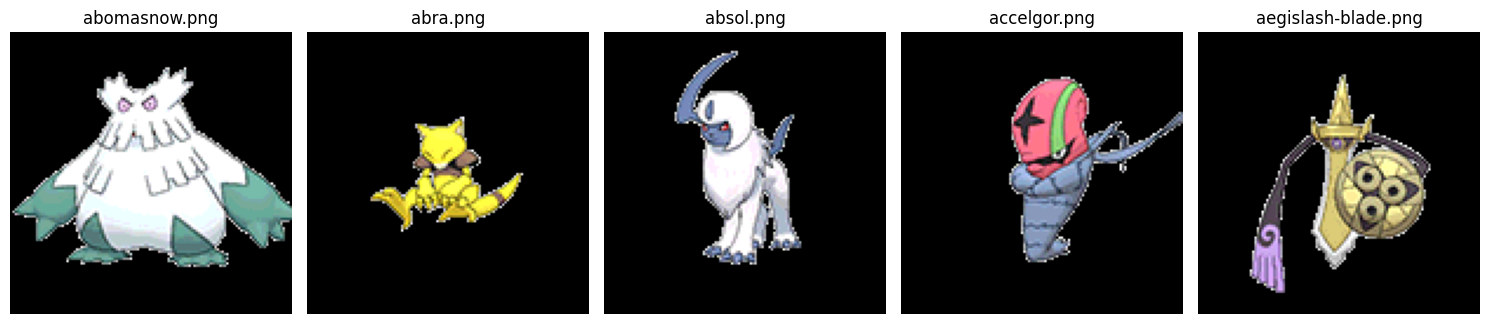

In [8]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# データセットのパス（ここは自分の環境に合わせて変更）
dataset_path = Path("/kaggle/input/datasets/vishalsubbiah/pokemon-images-and-types")  # ←名前を確認

images_dir = dataset_path / "images"

# 画像ファイル一覧（拡張子対応）
image_files = sorted(
    list(images_dir.glob("*.png")) +
    list(images_dir.glob("*.jpg")) +
    list(images_dir.glob("*.jpeg"))
)

# 上から5枚取得
image_files = image_files[:5]

# 表示
fig, axes = plt.subplots(1, len(image_files), figsize=(15, 5))

if len(image_files) == 1:
    axes = [axes]

for ax, img_path in zip(axes, image_files):
    img = Image.open(img_path).convert("RGB")
    ax.imshow(img)
    ax.set_title(img_path.name)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [9]:
if len(image_files) == 0:
    raise ValueError("画像が見つかりません")

image_1 = Image.open(image_files[0]).convert("RGB")

print("image_1 path:", image_files[0])

image_1 path: /kaggle/input/datasets/vishalsubbiah/pokemon-images-and-types/images/abomasnow.png


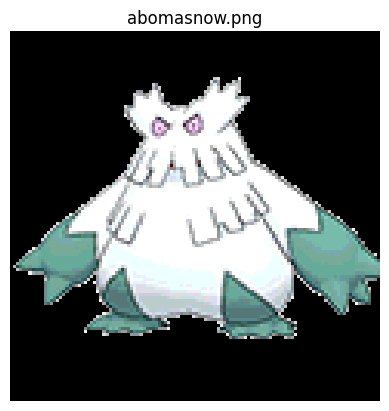

In [10]:
import matplotlib.pyplot as plt

plt.imshow(image_1)
plt.title(image_files[0].name)
plt.axis("off")
plt.show()

**上記画像をモデルに入力する**

In [11]:
import torch
from transformers import GenerationConfig
import time  # ← 追加


# 画像について説明させるプロンプト
user_prompt = "Please answer in Japanese. Describe this image."

# Gemma4 用のマルチモーダル chat 形式
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image_1},
            {"type": "text", "text": user_prompt},
        ],
    }
]

# chat template を適用
chat_text = processor.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=False,
)

# 入力作成
inputs = processor(
    text=chat_text,
    images=[image_1],
    return_tensors="pt",
)

# 生成設定
gen_config = GenerationConfig(
    max_new_tokens=1024,
    do_sample=False,
    temperature=1.0,
)

model.eval()

# 推論
start_time = time.time()  # ← 追加

with torch.no_grad():
    output_ids = model.generate(
        **inputs,
        generation_config=gen_config
    )

end_time = time.time()  # ← 追加
inference_time = end_time - start_time  # ← 追加

# デコード
generated_text = processor.batch_decode(
    output_ids,
    skip_special_tokens=True,
)[0]

print("=== Prompt ===")
print(user_prompt)
print("\n=== Gemma4 Answer ===")
print(generated_text)

print("\n=== Inference Time ===")  # ← 追加
print(f"{inference_time:.4f} seconds")

=== Prompt ===
Please answer in Japanese. Describe this image.

=== Gemma4 Answer ===
user




Please answer in Japanese. Describe this image.
model
この画像は、ポケモンシリーズに登場する「**ハ雪姫（はなゆきひめ）**」というポケモンの図鑑イラスト（またはゲーム内のグラフィック）です。

**見た目の特徴:**

*   **全体的な色:** 主に白と淡い水色（または青緑色）で構成されています。
*   **体型:** 丸みを帯びた、雪のような、あるいは幽霊のような印象の体型をしています。
*   **頭部:** 白い毛皮のような部分があり、目元は紫がかった色をしています。
*   **胴体:** 大きくふっくらとした白い部分が特徴的です。
*   **翼/装飾:** 体の側面や下部には、淡い水色や青緑色の、羽やローブのような形状のパーツがついています。

全体として、雪や氷、あるいは幻想的な雰囲気をまとった、可愛らしくも神秘的な外見をしています。

=== Inference Time ===
26.6972 seconds


**結果と考察：**

**ポケモンであることは捉えられている。**

**花雪姫っというキャラクターは存在しない->ポケモンを十分に学習できていない可能性が高い**

**->ファインチューニングをして検証する**

**->参考：https://chatgpt.com/share/69ddad2e-8b98-83a2-938f-2e690c7e7ec0**

**色の特徴は捉えらている。理由は白という特徴から、どのポケモンかを推論することができてる。**

**プロンプトに対する言語回答(文章作成)は十分にできている。**


**他の画像での検証**

**今回は画像の解像度がより高い画像を選択する**


**動物の画像を使用す**

**https://www.kaggle.com/datasets/iamsouravbanerjee/animal-image-dataset-90-different-animals**


In [12]:
from pathlib import Path

root = Path("/kaggle/input/datasets/iamsouravbanerjee/animal-image-dataset-90-different-animals/animals")

print("=== root直下 ===")
for p in sorted(root.iterdir()):
    print(p)

print("\n=== 1段下も確認 ===")
for p in sorted(root.iterdir()):
    if p.is_dir():
        print(f"\n[{p.name}]")
        for c in sorted(p.iterdir())[:10]:
            print("  ", c)

=== root直下 ===
/kaggle/input/datasets/iamsouravbanerjee/animal-image-dataset-90-different-animals/animals/animals

=== 1段下も確認 ===

[animals]
   /kaggle/input/datasets/iamsouravbanerjee/animal-image-dataset-90-different-animals/animals/animals/antelope
   /kaggle/input/datasets/iamsouravbanerjee/animal-image-dataset-90-different-animals/animals/animals/badger
   /kaggle/input/datasets/iamsouravbanerjee/animal-image-dataset-90-different-animals/animals/animals/bat
   /kaggle/input/datasets/iamsouravbanerjee/animal-image-dataset-90-different-animals/animals/animals/bear
   /kaggle/input/datasets/iamsouravbanerjee/animal-image-dataset-90-different-animals/animals/animals/bee
   /kaggle/input/datasets/iamsouravbanerjee/animal-image-dataset-90-different-animals/animals/animals/beetle
   /kaggle/input/datasets/iamsouravbanerjee/animal-image-dataset-90-different-animals/animals/animals/bison
   /kaggle/input/datasets/iamsouravbanerjee/animal-image-dataset-90-different-animals/animals/animals/b

=== フォルダ一覧 ===
antelope
badger
bat
bear
bee
beetle
bison
boar
butterfly
cat
caterpillar
chimpanzee
cockroach
cow
coyote
crab
crow
deer
dog
dolphin
donkey
dragonfly
duck
eagle
elephant
flamingo
fly
fox
goat
goldfish
goose
gorilla
grasshopper
hamster
hare
hedgehog
hippopotamus
hornbill
horse
hummingbird
hyena
jellyfish
kangaroo
koala
ladybugs
leopard
lion
lizard
lobster
mosquito
moth
mouse
octopus
okapi
orangutan
otter
owl
ox
oyster
panda
parrot
pelecaniformes
penguin
pig
pigeon
porcupine
possum
raccoon
rat
reindeer
rhinoceros
sandpiper
seahorse
seal
shark
sheep
snake
sparrow
squid
squirrel
starfish
swan
tiger
turkey
turtle
whale
wolf
wombat
woodpecker
zebra

フォルダ数: 90

=== 表示対象フォルダ ===
antelope
badger
bat
bear
bee
antelope: 02f4b3be2d.jpg
badger: 00f56e5c92.jpg
bat: 003bd60fa9.jpg
bear: 039b2ae790.jpg
bee: 0d562e4829.jpg


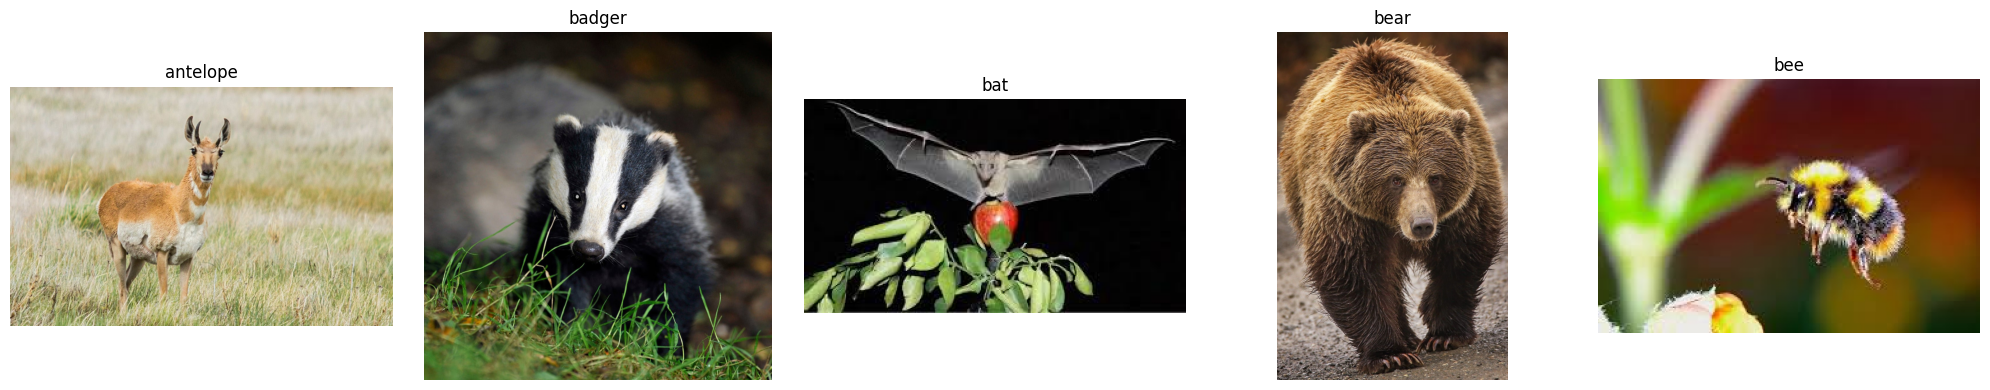

In [13]:
# =========================
# 1. パス指定
# =========================
animals_path = Path("/kaggle/input/datasets/iamsouravbanerjee/animal-image-dataset-90-different-animals/animals/animals")

if not animals_path.exists():
    raise FileNotFoundError(f"指定したパスが存在しません: {animals_path}")

# =========================
# 2. フォルダ一覧表示
# =========================
folders = sorted([f for f in animals_path.iterdir() if f.is_dir()])

print("=== フォルダ一覧 ===")
for f in folders:
    print(f.name)

print(f"\nフォルダ数: {len(folders)}")

# =========================
# 3. 上から5フォルダ取得
# =========================
selected_folders = folders[:5]

print("\n=== 表示対象フォルダ ===")
for f in selected_folders:
    print(f.name)

# =========================
# 4. 各フォルダから1枚ずつ画像取得
# =========================
images = []
titles = []

valid_exts = {".png", ".jpg", ".jpeg", ".webp", ".bmp"}

for folder in selected_folders:
    image_files = sorted([
        p for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() in valid_exts
    ])

    if len(image_files) > 0:
        img_path = image_files[0]
        img = Image.open(img_path).convert("RGB")
        images.append(img)
        titles.append(folder.name)
        print(f"{folder.name}: {img_path.name}")
    else:
        print(f"No images in {folder.name}")

# =========================
# 5. 画像表示
# =========================
if len(images) == 0:
    raise ValueError("画像が1枚も見つかりませんでした。")

fig, axes = plt.subplots(1, len(images), figsize=(4 * len(images), 4))

if len(images) == 1:
    axes = [axes]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

フォルダ: lizard
画像パス: /kaggle/input/datasets/iamsouravbanerjee/animal-image-dataset-90-different-animals/animals/animals/lizard/3a70eae985.jpg


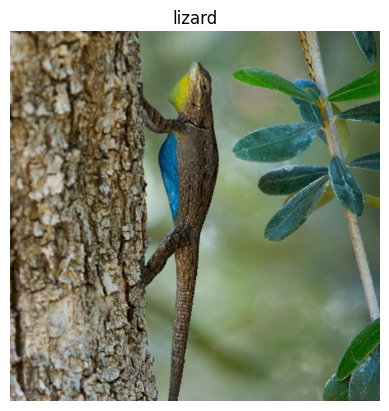

In [14]:
import random


folders = [f for f in animals_path.iterdir() if f.is_dir()]

# ランダムにフォルダ選択
selected_folder = random.choice(folders)

# 画像ファイル一覧取得（拡張子対応）
image_files = (
    list(selected_folder.glob("*.jpg")) +
    list(selected_folder.glob("*.jpeg")) +
    list(selected_folder.glob("*.png"))
)

# ランダムに1枚選択
selected_image_path = random.choice(image_files)

# 画像読み込み
animal_image = Image.open(selected_image_path).convert("RGB")

# 確認表示
print("フォルダ:", selected_folder.name)
print("画像パス:", selected_image_path)

# 表示
import matplotlib.pyplot as plt

plt.imshow(animal_image)
plt.axis("off")
plt.title(selected_folder.name)
plt.show()

**上記画像をモデルに入力する**

In [15]:
import torch
from transformers import GenerationConfig
import time  # ← 追加


# 画像について説明させるプロンプト
user_prompt = "Please answer in Japanese. Describe this image."

# Gemma4 用のマルチモーダル chat 形式
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": animal_image},
            {"type": "text", "text": user_prompt},
        ],
    }
]

# chat template を適用
chat_text = processor.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=False,
)

# 入力作成
inputs = processor(
    text=chat_text,
    images=[animal_image],
    return_tensors="pt",
)

# 生成設定
gen_config = GenerationConfig(
    max_new_tokens=1024,
    do_sample=False,
    temperature=1.0,
)

model.eval()

# 推論
start_time = time.time()  # ← 追加

with torch.no_grad():
    output_ids = model.generate(
        **inputs,
        generation_config=gen_config
    )

end_time = time.time()  # ← 追加
inference_time = end_time - start_time  # ← 追加

# デコード
generated_text = processor.batch_decode(
    output_ids,
    skip_special_tokens=True,
)[0]

print("=== Prompt ===")
print(user_prompt)
print("\n=== Gemma4 Answer ===")
print(generated_text)

print("\n=== Inference Time ===")  # ← 追加
print(f"{inference_time:.4f} seconds")

=== Prompt ===
Please answer in Japanese. Describe this image.

=== Gemma4 Answer ===
user




Please answer in Japanese. Describe this image.
model
この画像は、木の幹に止まっているトカゲのような爬虫類をクローズアップで捉えた写真です。

**画像の詳細な説明:**

* **被写体（トカゲ）:** 中央に、茶色っぽい体色のトカゲが垂直に木の幹を登っているか、それに寄りかかっている様子が見えます。このトカゲは、背中や側面が茶色や灰色がかった色をしていますが、首元や背中の上部には鮮やかな**黄緑色**の斑点が見られます。また、胴体の側面には目立つ**青色**の模様（おそらく皮膚の色や鱗の色）があります。体つきはがっしりとしており、尾は長く見えます。
* **背景と環境:**
    * **左側:** 大きく、質感のある**木の幹**が画面の大部分を占めています。幹の樹皮はゴツゴツとしており、茶色や灰色の複雑なテクスチャを持っています。
    * **右側:** 背景はぼかされていますが、緑の葉を持つ植物が写り込んでいます。これらの葉は濃い緑色から青みがかった緑色をしており、自然豊かな環境であることがわかります。背景全体は明るく、ややぼかされた（ボケた）トーンで、被写体に視線を集める効果を生んでいます。

**全体的な印象:**

この写真は、自然界の生き物のディテールと、その生息環境の質感を対比させて捉えた、生き生きとした自然写真です。トカゲの鮮やかな色彩と、木の幹の素朴な質感が印象的です。

=== Inference Time ===
44.5555 seconds
